[*********************100%***********************]  1 of 1 completed

Buy-and-Hold Strategy Return and Risk: 27.19% and 54.03%
SR Strategy Return and Risk: -84.27% and 53.83%


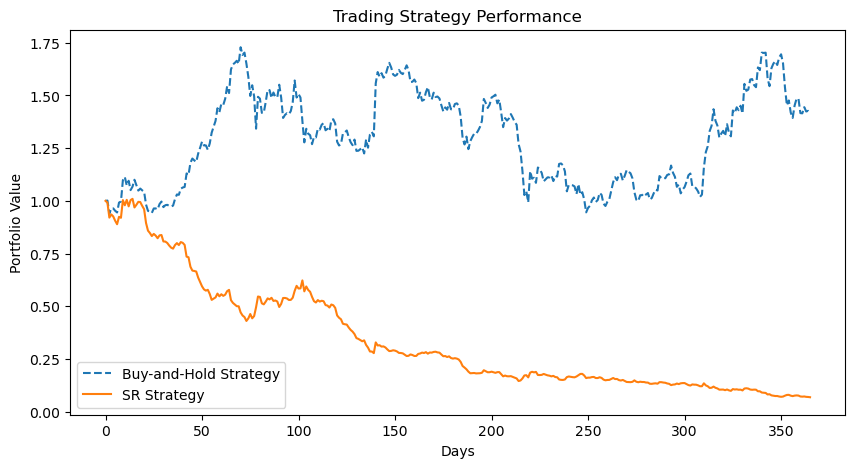

In [7]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt


ticker = 'ETH-USD'
data = yf.download(ticker, start='2024-01-01', end='2025-01-01')

fee = 0.01
sr_sell = 0.5
sr_buy = 0.5

data['returns'] = data['Close'].pct_change()
data['scaled price'] = data['Close'] / (10 ** np.floor(np.log10(data['Close'])))
data['S&R'] = data['scaled price'] % 1

data['signal'] = (data['S&R'] < sr_buy).astype(int) - (data['S&R'] > sr_sell).astype(int)

BnH_return = data['returns'][1:].to_numpy()
SR_return = (data['returns'][1:].to_numpy() * data['signal'][:-1].to_numpy()) - (fee * abs(data['signal'][:-1].to_numpy()))

BnH = np.prod(1 + BnH_return) ** (252 / len(BnH_return)) - 1
SR = np.prod(1 + SR_return) ** (252 / len(SR_return)) - 1

BnH_risk = np.std(BnH_return) * np.sqrt(252)
SR_risk = np.std(SR_return) * np.sqrt(252)

print(f'Buy-and-Hold Strategy Return and Risk: {round(BnH * 100, 2)}% and {round(BnH_risk * 100, 2)}%')
print(f'SR Strategy Return and Risk: {round(SR * 100, 2)}% and {round(SR_risk * 100, 2)}%')

plt.figure(figsize=(10, 5))
plt.plot(np.append(1, np.cumprod(1 + BnH_return)), label='Buy-and-Hold Strategy', linestyle='--')
plt.plot(np.append(1, np.cumprod(1 + SR_return)), label='SR Strategy', linestyle='-')
plt.legend()
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Trading Strategy Performance")
plt.show()

[*********************100%***********************]  1 of 1 completed


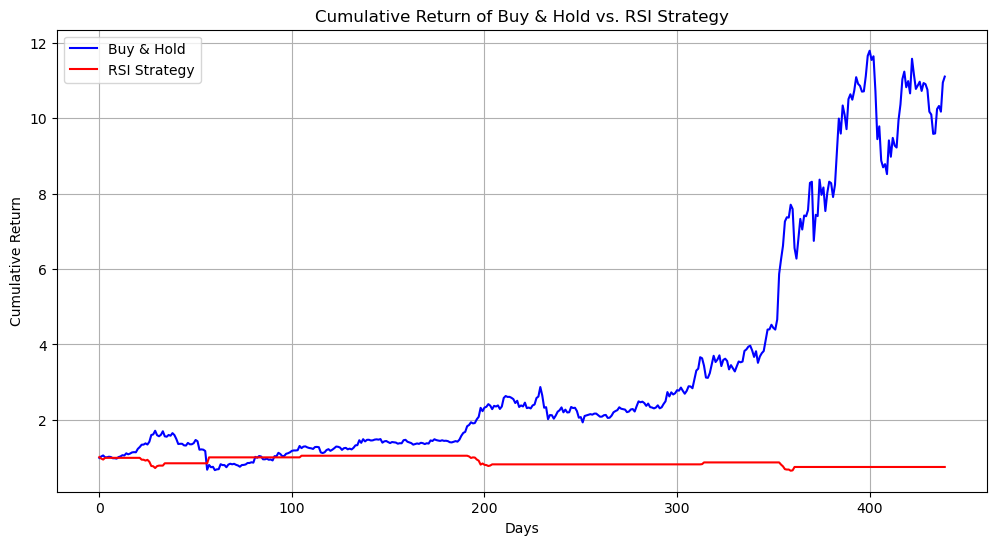

Buy-and-hold strategy return and risk: 297.01% and 83.05%, Max Drawdown: -61.08%, Sharpe Ratio: 2.08
RSI strategy return and risk: -15.28% and 28.76%, Max Drawdown: -37.99%, Sharpe Ratio: -0.50


In [ ]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


stock = 'ETH-USD'
data = yf.download(stock, start='2020-01-01', end='2021-03-31')

rsi_period = 14
rsi_oversold = 20
rsi_overbought = 80
fee = 0.000
risk_free_rate = 0.02

data['returns'] = data['Close'].pct_change()
data['Up'] = np.maximum(data['Close'].diff(),0)
data['Down'] = np.maximum(-data['Close'].diff(),0)
data['RS'] = data['Up'].rolling(rsi_period).mean()/data['Down'].rolling(rsi_period).mean()
data['RSI'] = 100 - 100/(1+data['RS'])

start = rsi_period
data['signal'] = 1*(data['RSI'] < rsi_oversold) - 1*(data['RSI'] > rsi_overbought)
BnH_return = np.array(data['returns'][start+1:])
RSI_return = np.array(data['returns'][start+1:]) * np.array(data['signal'][start:-1 ]) - (fee * abs(data['signal'][start+1:]))
BnH_cum_return = np.cumprod(1 + BnH_return) 
RSI_cum_return = np.cumprod(1 + RSI_return)

BnH = np.prod(1+BnH_return)**(252/len(BnH_return))-1
RSI = np.prod(1+RSI_return)**(252/len(RSI_return))-1
BnH_risk = np.std(BnH_return)*(252)**(1/2)
RSI_risk = np.std(RSI_return)*(252)**(1/2)

def max_drawdown(returns):
    cum_returns = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - peak) / peak
    return np.min(drawdown)  

BnH_drawdown = max_drawdown(BnH_return)
RSI_drawdown = max_drawdown(RSI_return)


def sharpe_ratio(returns, risk_free_rate):
    excess_return = np.mean(returns) - (risk_free_rate / 252) 
    return excess_return / np.std(returns) * np.sqrt(252) 

BnH_sharpe = sharpe_ratio(BnH_return, risk_free_rate)
RSI_sharpe = sharpe_ratio(RSI_return, risk_free_rate)

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(BnH_cum_return)), BnH_cum_return, label="Buy & Hold", color='blue')
plt.plot(np.arange(len(RSI_cum_return)), RSI_cum_return, label="RSI Strategy", color='red')
plt.xlabel("Days")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Return of Buy & Hold vs. RSI Strategy")
plt.legend()
plt.grid()
plt.show()
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Printing results
print(f'Buy-and-hold strategy return and risk: {round(BnH*100,2)}% and {round(BnH_risk*100,2)}%, Max Drawdown: {BnH_drawdown*100:.2f}%, Sharpe Ratio: {BnH_sharpe:.2f}')
print(f'RSI strategy return and risk: {round(RSI*100,2)}% and {round(RSI_risk*100,2)}%, Max Drawdown: {RSI_drawdown*100:.2f}%, Sharpe Ratio: {RSI_sharpe:.2f}')

[*********************100%***********************]  1 of 1 completed


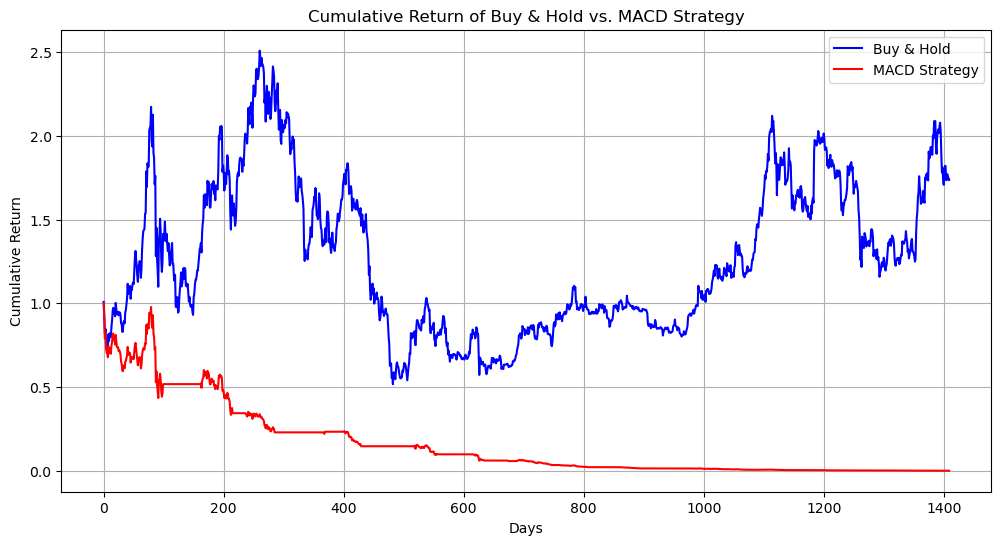

Buy-and-hold strategy return and risk: 10.36% and 63.82%, Max Drawdown: -79.35%, Sharpe Ratio: 0.44
MACD strategy return and risk: -68.12% and 48.19%, Max Drawdown: -99.83%, Sharpe Ratio: -2.16


In [10]:

import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


ticker = "ETH-USD"
data = yf.download(ticker, start="2021-01-01", end="2025-01-01")
short_ma = 20
long_ma = 50
fee = 0.01
risk_free_rate = 0.02

data['MA'+str(short_ma)] = data['Close'].rolling(short_ma).mean()
data['MA'+str(long_ma)] = data['Close'].rolling(long_ma).mean()
data['return'] = data['Close'].pct_change()

start = long_ma
data['signal'] = (data['MA'+str(short_ma)] > data['MA'+str(long_ma)]).astype(int)

BnH_return = np.array(data['return'][start+1:])
MACD_return = np.array(data['return'][start+1:]) * np.array(data['signal'][start+1:]) - (fee * abs(data['signal'][start+1:]))

BnH_cum_return = np.cumprod(1 + BnH_return) 
MACD_cum_return = np.cumprod(1 + MACD_return)

BnH = np.prod(1+BnH_return)**(252/len(BnH_return))-1
MACD = np.prod(1+MACD_return)**(252/len(MACD_return))-1
BnH_risk = np.std(BnH_return)*(252)**(1/2)
MACD_risk = np.std(MACD_return)*(252)**(1/2)

def max_drawdown(returns):
    cum_returns = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - peak) / peak
    return np.min(drawdown) 

BnH_drawdown = max_drawdown(BnH_return)
MACD_drawdown = max_drawdown(MACD_return)

def sharpe_ratio(returns, risk_free_rate):
    excess_return = np.mean(returns) - (risk_free_rate / 252) 
    return excess_return / np.std(returns) * np.sqrt(252) 

BnH_sharpe = sharpe_ratio(BnH_return, risk_free_rate)
MACD_sharpe = sharpe_ratio(MACD_return, risk_free_rate)


plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(BnH_cum_return)), BnH_cum_return, label="Buy & Hold", color='blue')
plt.plot(np.arange(len(MACD_cum_return)), MACD_cum_return, label="MACD Strategy", color='red')
plt.xlabel("Days")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Return of Buy & Hold vs. MACD Strategy")
plt.legend()
plt.grid()
plt.show()
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print(f'Buy-and-hold strategy return and risk: {round(BnH*100,2)}% and {round(BnH_risk*100,2)}%, Max Drawdown: {BnH_drawdown*100:.2f}%, Sharpe Ratio: {BnH_sharpe:.2f}')
print(f'MACD strategy return and risk: {round(MACD*100,2)}% and {round(MACD_risk*100,2)}%, Max Drawdown: {MACD_drawdown*100:.2f}%, Sharpe Ratio: {MACD_sharpe:.2f}')

[*********************100%***********************]  1 of 1 completed
C:\Users\Anshpreet Singh\AppData\Local\Temp\ipykernel_11920\1463382906.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if closep[i-1] < openp[i-1] and closep[i] > openp[i] and closep[i] > openp[i-1] and openp[i] < closep[i-1]:


STRATEGY METRICS:
Return: 218070.79%
Volatility: 35.14%
Sharpe: 2.3
Max Drawdown: 0.0%
Return w/ TC+Slippage: 112421.78%

BUY & HOLD METRICS:
Return: 503.2%
Volatility: 84.25%
Sharpe: 0.61
Max Drawdown: -83.25%


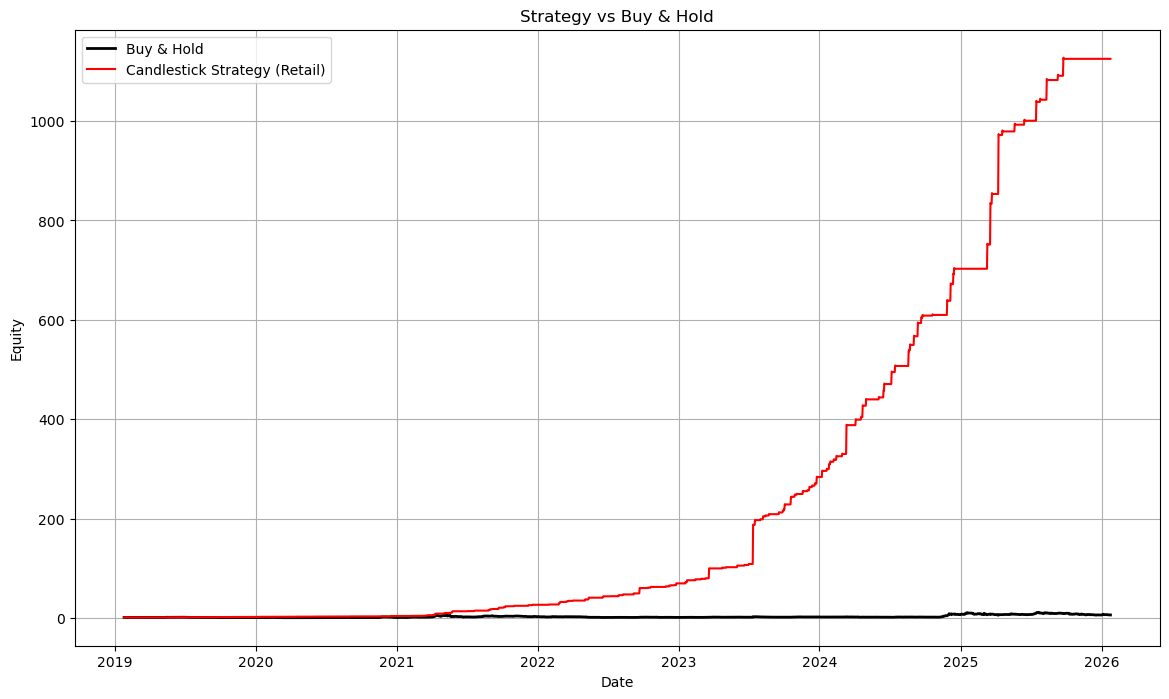

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "XRP-USD"
start_date = (pd.Timestamp.today() - pd.DateOffset(years=7)).strftime("%Y-%m-%d")
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
transaction_cost = 0.0015
slippage = 0.0005

data = yf.download(ticker, start=start_date, end=end_date)
openp = data["Open"].squeeze()
closep = data["Close"].squeeze()

def calc_metrics(equity):
    returns = equity.pct_change().dropna()
    total_return = equity.iloc[-1]/equity.iloc[0] - 1
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0
    drawdown = (equity/equity.cummax() - 1).min()
    return total_return, annual_vol, sharpe, drawdown

def strategy(openp, closep):
    position = np.zeros(len(closep))
    for i in range(1, len(closep)):
        if closep[i-1] < openp[i-1] and closep[i] > openp[i] and closep[i] > openp[i-1] and openp[i] < closep[i-1]:
            position[i] = 1
        else:
            position[i] = 0
    position = pd.Series(position, index=closep.index).ffill().fillna(0).values
    returns = closep.pct_change().fillna(0).values
    equity = pd.Series((returns * position + 1).cumprod(), index=closep.index)
    return equity, position

equity, position = strategy(openp, closep)

returns = closep.pct_change().fillna(0).values
strategy_returns = returns * position
trades = np.abs(np.diff(position, prepend=0))
strategy_returns = strategy_returns - trades * (transaction_cost + slippage)
equity_tc = pd.Series((1 + strategy_returns).cumprod(), index=closep.index)

total, vol, sharpe, dd = calc_metrics(equity)
total_tc, _, _, _ = calc_metrics(equity_tc)

bnh_equity = (closep.pct_change().fillna(0) + 1).cumprod()
bnh_total, bnh_vol, bnh_sharpe, bnh_dd = calc_metrics(bnh_equity)

print("STRATEGY METRICS:")
print(f"Return: {round(total*100, 2)}%")
print(f"Volatility: {round(vol*100, 2)}%")
print(f"Sharpe: {round(sharpe, 2)}")
print(f"Max Drawdown: {round(dd*100, 2)}%")
print(f"Return w/ TC+Slippage: {round(total_tc*100, 2)}%")
print()
print("BUY & HOLD METRICS:")
print(f"Return: {round(bnh_total*100, 2)}%")
print(f"Volatility: {round(bnh_vol*100, 2)}%")
print(f"Sharpe: {round(bnh_sharpe, 2)}")
print(f"Max Drawdown: {round(bnh_dd*100, 2)}%")

plt.figure(figsize=(14, 8))
plt.plot(bnh_equity, label="Buy & Hold", color='black', linewidth=2)
plt.plot(equity_tc, label="Candlestick Strategy (Retail)", color='red')
plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed


Return: 187.16%
Volatility: 5.41%
Sharpe: 6.57
Max Drawdown: 0.0%
Return w/ TC+Slippage: -48.69%

BUY & HOLD METRICS:
Return: 79.16%
Volatility: 15.24%
Sharpe: 1.36
Max Drawdown: -18.76%


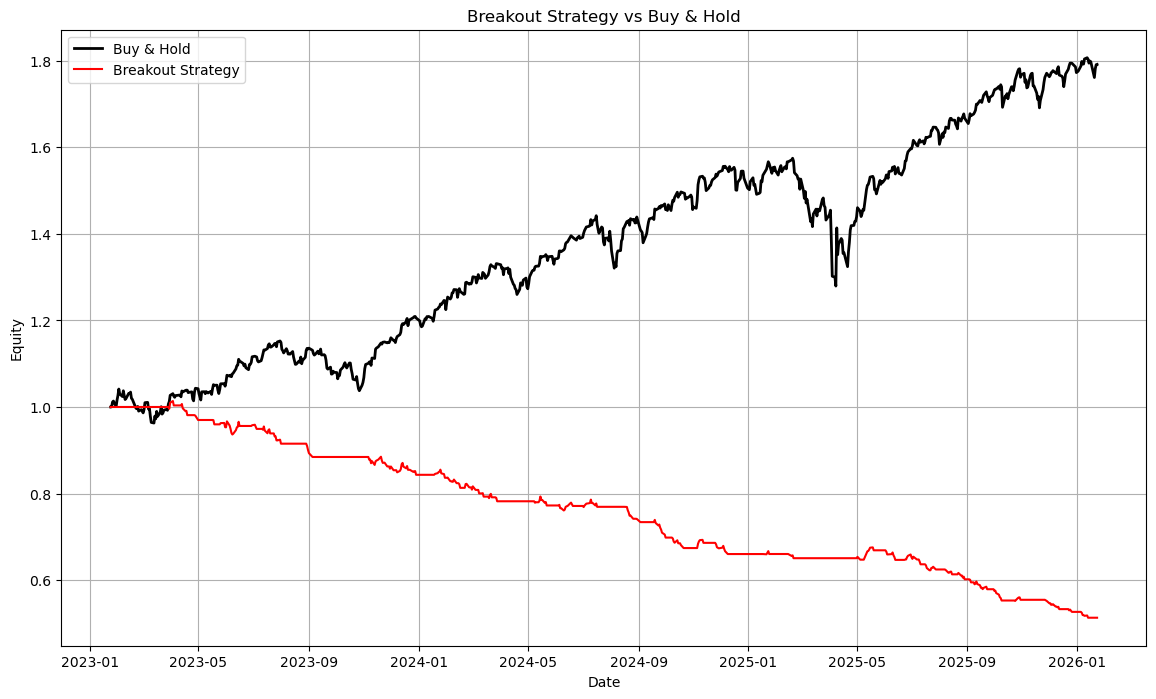

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "SPY"
start_date = (pd.Timestamp.today() - pd.DateOffset(years=3)).strftime("%Y-%m-%d")
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
transaction_cost = 0.01
slippage = 0.0

data = yf.download(ticker, start=start_date, end=end_date)
price = data["Close"].squeeze()

def calc_metrics(equity):
    returns = equity.pct_change().dropna()
    total_return = equity.iloc[-1]/equity.iloc[0] - 1
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0
    drawdown = (equity/equity.cummax() - 1).min()
    return total_return, annual_vol, sharpe, drawdown

def breakout_strategy(price, window=20):
    high20 = price.rolling(window).min()
    low20 = price.rolling(window).max()
    position = np.where(price > high20.shift(1), 1, 0)
    position = np.where(price < low20.shift(1), 0, position)
    position = pd.Series(position, index=price.index).ffill().fillna(0).values
    returns = price.pct_change().fillna(0).values
    equity = pd.Series((returns * position + 1).cumprod(), index=price.index)
    return equity, position

equity, position = breakout_strategy(price)

returns = price.pct_change().fillna(0).values
strategy_returns = returns * position
trades = np.abs(np.diff(position, prepend=0))
strategy_returns = strategy_returns - trades * (transaction_cost + slippage)
equity_tc = pd.Series((1 + strategy_returns).cumprod(), index=price.index)

total, vol, sharpe, dd = calc_metrics(equity)
total_tc, _, _, _ = calc_metrics(equity_tc)

bnh_equity = (price.pct_change().fillna(0) + 1).cumprod()
bnh_total, bnh_vol, bnh_sharpe, bnh_dd = calc_metrics(bnh_equity)

print(f"Return: {round(total*100, 2)}%")
print(f"Volatility: {round(vol*100, 2)}%")
print(f"Sharpe: {round(sharpe, 2)}")
print(f"Max Drawdown: {round(dd*100, 2)}%")
print(f"Return w/ TC+Slippage: {round(total_tc*100, 2)}%")
print()
print("BUY & HOLD METRICS:")
print(f"Return: {round(bnh_total*100, 2)}%")
print(f"Volatility: {round(bnh_vol*100, 2)}%")
print(f"Sharpe: {round(bnh_sharpe, 2)}")
print(f"Max Drawdown: {round(bnh_dd*100, 2)}%")

plt.figure(figsize=(14, 8))
plt.plot(bnh_equity, label="Buy & Hold", color='black', linewidth=2)
plt.plot(equity_tc, label="Breakout Strategy", color='red')
plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed
C:\Users\Anshpreet Singh\AppData\Local\Temp\ipykernel_47140\1516279169.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fib_price = high[i] - level * (high[i] - low[i])
C:\Users\Anshpreet Singh\AppData\Local\Temp\ipykernel_47140\1516279169.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if price[i] <= fib_price:
C:\Users\Anshpreet Singh\AppData\Local\Temp\ipykernel_47140\1516279169.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent

FIBONACCI RETAIL STRATEGY METRICS:
Return: 0.14%
Volatility: 11.98%
Sharpe: 0.06
Max Drawdown: -18.42%
Return w/ TC+Slippage: 0.14%

BUY & HOLD METRICS:
Return: 79.16%
Volatility: 15.24%
Sharpe: 1.36
Max Drawdown: -18.76%


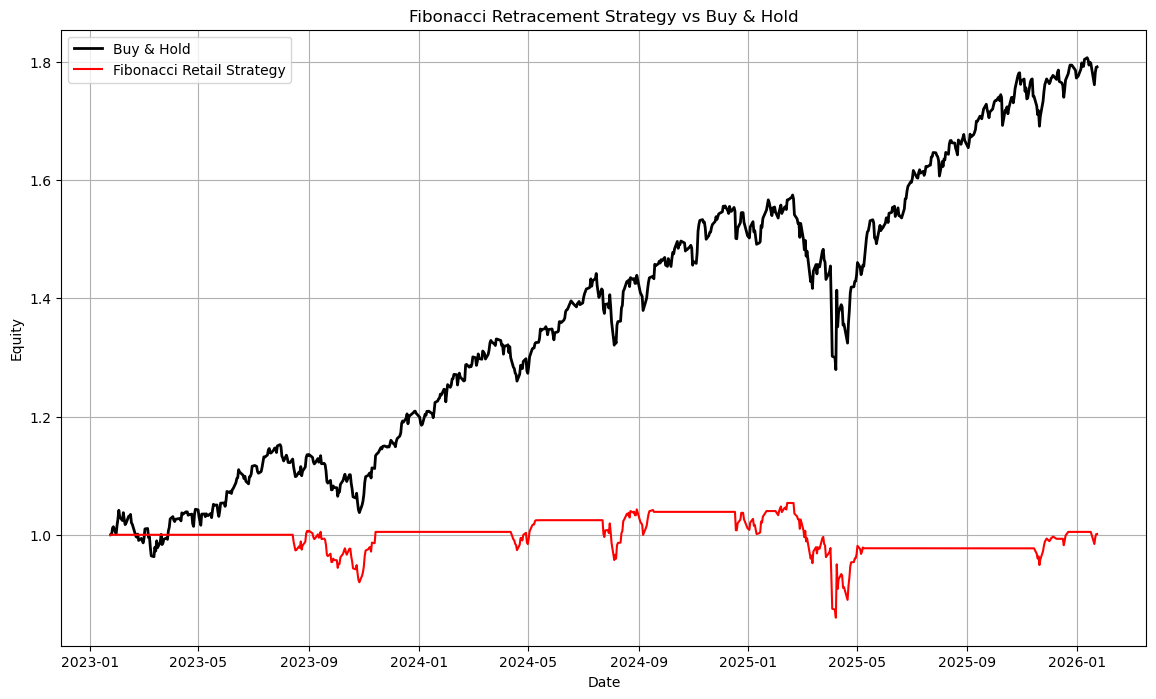

In [58]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "SPY"
start_date = (pd.Timestamp.today() - pd.DateOffset(years=3)).strftime("%Y-%m-%d")
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
transaction_cost = 0.00
slippage = 0.00

data = yf.download(ticker, start=start_date, end=end_date)
price = data["Close"].squeeze()

def calc_metrics(equity):
    returns = equity.pct_change().dropna()
    total_return = equity.iloc[-1]/equity.iloc[0] - 1
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0
    drawdown = (equity/equity.cummax() - 1).min()
    return total_return, annual_vol, sharpe, drawdown

def fibonacci_strategy(price, window=50):
    position = np.zeros(len(price))
    high = price.rolling(window).max()
    low = price.rolling(window).min()
    fib_levels = [0.382, 0.5, 0.618]
    
    for i in range(len(price)):
        buy_cond = False
        for level in fib_levels:
            fib_price = high[i] - level * (high[i] - low[i])
            if price[i] <= fib_price:
                buy_cond = True
        sell_cond = price[i] >= high[i]
        if buy_cond:
            position[i] = 1
        elif sell_cond:
            position[i] = 0
        else:
            if i > 0:
                position[i] = position[i-1]
    
    position = pd.Series(position, index=price.index).fillna(0).values
    returns = price.pct_change().fillna(0).values
    equity = pd.Series((returns * position + 1).cumprod(), index=price.index)
    return equity, position

equity, position = fibonacci_strategy(price)

returns = price.pct_change().fillna(0).values
strategy_returns = returns * position
trades = np.abs(np.diff(position, prepend=0))
strategy_returns = strategy_returns - trades * (transaction_cost + slippage)
equity_tc = pd.Series((1 + strategy_returns).cumprod(), index=price.index)

total, vol, sharpe, dd = calc_metrics(equity)
total_tc, _, _, _ = calc_metrics(equity_tc)

bnh_equity = (price.pct_change().fillna(0) + 1).cumprod()
bnh_total, bnh_vol, bnh_sharpe, bnh_dd = calc_metrics(bnh_equity)

print("FIBONACCI RETAIL STRATEGY METRICS:")
print(f"Return: {round(total*100,2)}%")
print(f"Volatility: {round(vol*100,2)}%")
print(f"Sharpe: {round(sharpe,2)}")
print(f"Max Drawdown: {round(dd*100,2)}%")
print(f"Return w/ TC+Slippage: {round(total_tc*100,2)}%")
print()
print("BUY & HOLD METRICS:")
print(f"Return: {round(bnh_total*100,2)}%")
print(f"Volatility: {round(bnh_vol*100,2)}%")
print(f"Sharpe: {round(bnh_sharpe,2)}")
print(f"Max Drawdown: {round(bnh_dd*100,2)}%")

plt.figure(figsize=(14,8))
plt.plot(bnh_equity, label="Buy & Hold", color='black', linewidth=2)
plt.plot(equity_tc, label="Fibonacci Retail Strategy", color='red')
plt.title("Fibonacci Retracement Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()
